# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


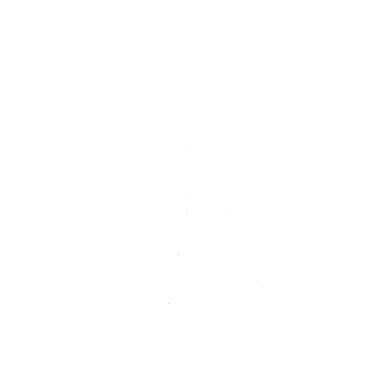

Threshold value: 50


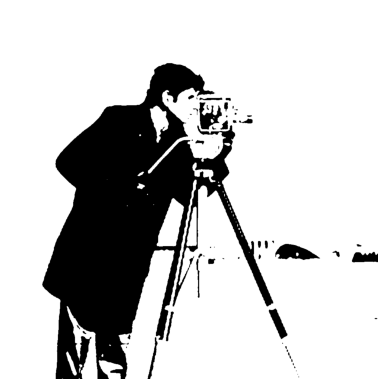

Threshold value: 100


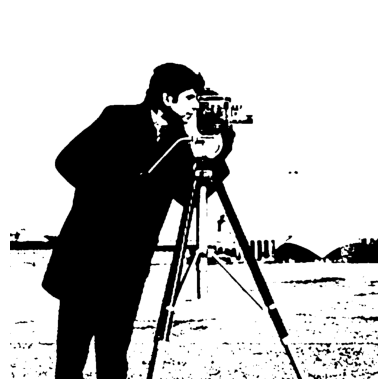

Threshold value: 150


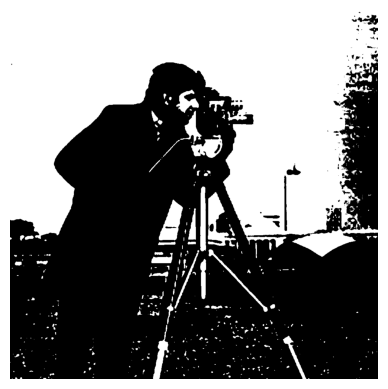

Threshold value: 200


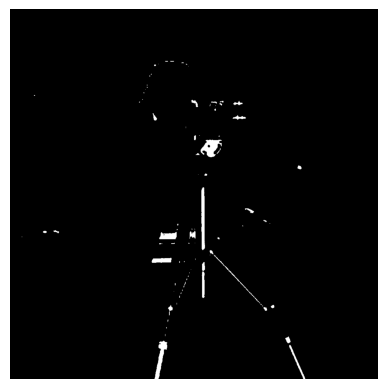

In [2]:
# Task 1: Thresholding

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("cameraman.png", 0)

threshold_values = [0, 50, 100, 150, 200]

for value in threshold_values:
    ret, result = cv2.threshold(img, value, 255, cv2.THRESH_BINARY)

    print("Threshold value:", value)

    plt.imshow(result, cmap="gray")
    plt.axis("off")
    plt.show()

Original Image:


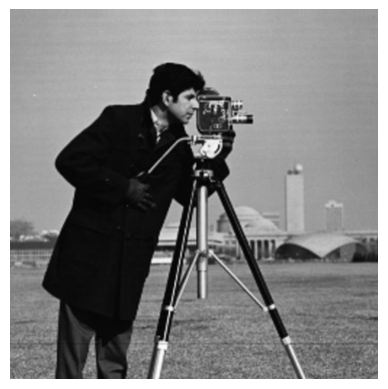

In [3]:
print("Original Image:")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

## Histograms

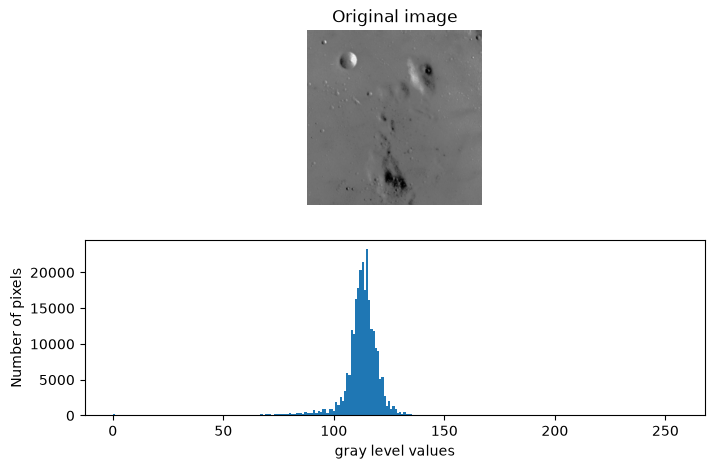

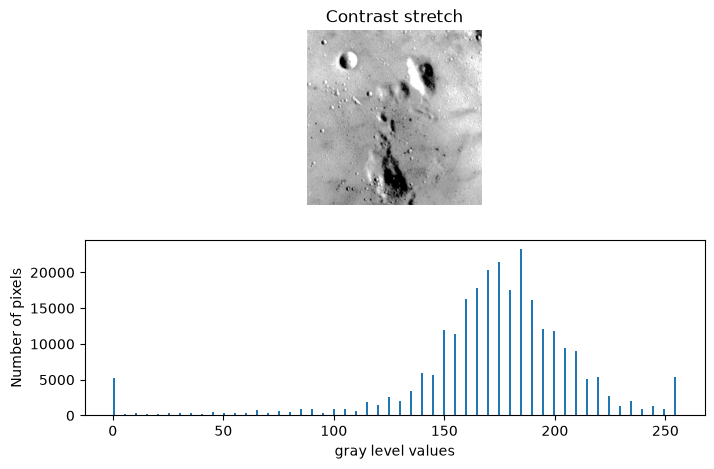

In [4]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


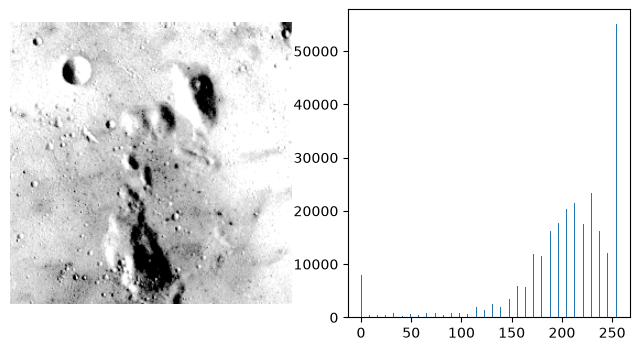

In [5]:
# Task 1: Contrast Stretching

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

moon = data.moon()

low, high = np.percentile(moon, (3, 80))

stretch = exposure.rescale_intensity(moon, in_range=(low, high))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(stretch, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(stretch.ravel(), bins=256)

plt.show()


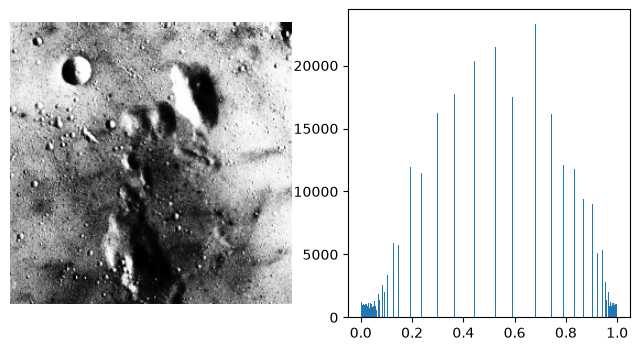

In [6]:
# Task 2: Histogram Equalization

from skimage import exposure

equal_img = exposure.equalize_hist(moon)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(equal_img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.hist(equal_img.ravel(), bins=256)

plt.show()


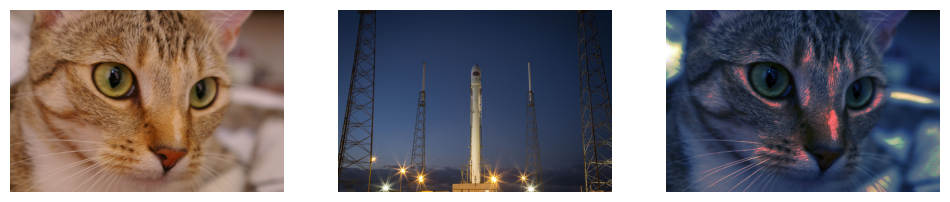

In [7]:
# Task 3: Histogram Matching

from skimage import data, exposure
import matplotlib.pyplot as plt

source = data.chelsea()
reference = data.rocket()

matched = exposure.match_histograms(source, reference, channel_axis=-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(source)
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(reference)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(matched)
plt.axis('off')

plt.show()
